In [43]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC


from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [3]:
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [51]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


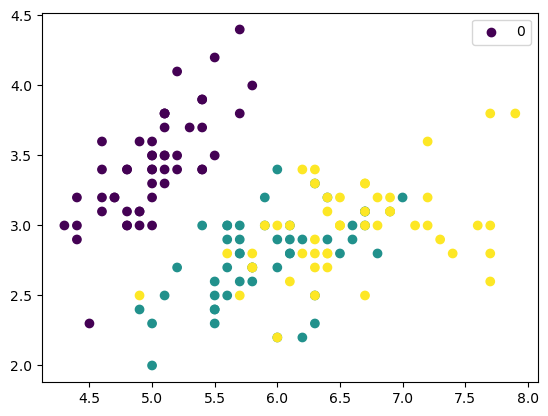

In [13]:
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'], c = df['target'], label = df['target'])
plt.legend(df['target'])
plt.show()

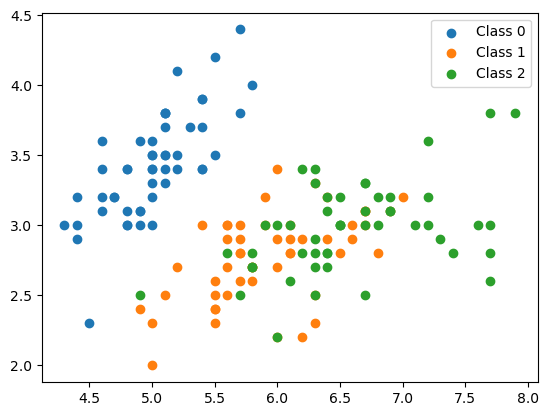

In [15]:
import matplotlib.pyplot as plt

for t in df['target'].unique():
    subset = df[df['target'] == t]
    plt.scatter(
        subset['sepal length (cm)'],
        subset['sepal width (cm)'],
        label=f"Class {t}"
    )

plt.legend()
plt.show()


In [16]:
X = df.drop('target', axis = 'columns')

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [17]:
y = df.target

In [32]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

In [33]:
x_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
58,6.6,2.9,4.6,1.3
97,6.2,2.9,4.3,1.3
129,7.2,3.0,5.8,1.6
114,5.8,2.8,5.1,2.4
146,6.3,2.5,5.0,1.9
...,...,...,...,...
113,5.7,2.5,5.0,2.0
64,5.6,2.9,3.6,1.3
15,5.7,4.4,1.5,0.4
125,7.2,3.2,6.0,1.8


In [34]:
model = SVC()

In [35]:
model.fit(x_train, y_train)

SVC()

In [36]:
model.score(x_test, y_test)

0.9666666666666667

In [37]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 0.18257418583505536
R²: 0.9401197604790419


In [41]:
def classifyer (model, x_train, x_test, y_train, y_test):
    model = model
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    score = model.score(x_test, y_test)
    print (f'accuracy is {score}')
    print (confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [42]:
classifyer (SVC(), x_train, x_test, y_train, y_test)

accuracy is 0.9666666666666667
[[10  0  0]
 [ 0 12  1]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.92      0.96        13
           2       0.88      1.00      0.93         7

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [44]:


def classifier(model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"Model: {model.__class__.__name__}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

    return acc

In [46]:
classifier (SVC(), x_train, x_test, y_train, y_test)

Model: SVC
Accuracy: 0.9667
Confusion Matrix:
[[10  0  0]
 [ 0 12  1]
 [ 0  0  7]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.92      0.96        13
           2       0.88      1.00      0.93         7

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30

--------------------------------------------------


0.9666666666666667

In [47]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [48]:
models = {
    "SVC": SVC(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}


In [49]:
results = {}

for name, model in models.items():
    acc = classifier(model, x_train, x_test, y_train, y_test)
    results[name] = acc

Model: SVC
Accuracy: 0.9667
Confusion Matrix:
[[10  0  0]
 [ 0 12  1]
 [ 0  0  7]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.92      0.96        13
           2       0.88      1.00      0.93         7

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30

--------------------------------------------------
Model: RandomForestClassifier
Accuracy: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0 13  0]
 [ 0  0  7]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted av

In [50]:


results_df = pd.DataFrame.from_dict(
    results, orient="index", columns=["Accuracy"]
).sort_values(by="Accuracy", ascending=False)

results_df

,Accuracy
Random Forest,1.000000
Logistic Regression,1.000000
SVC,0.966667
KNN,0.966667
